## Data-driven modelling of cooperative decision-making under resource inequality in an urban collective-risk dilemma

##### Game Structure:
Six players participate in each game.
Players have different initial endowments.
The game lasts for 10 rounds.
Players can choose to treat 0, 2, or 4 MU in each round.
The goal is for all players to collectively reach 120 MU to win.
If they reach the goal, they keep their unspent MU; if not, they lose.

There are two main datasets of the Collective Risk Game experiment:
- df_users: Dataframe of the registered users. Each row represents a single player with multiple columns for their characteristics (e.g., initial endowment, contributions per round, final balance).
- df_games: Dataframe of the registered games. Each row represents a single game (played by six people), capturing cumulative or summary information for that game (e.g., total contributions, win/lose status).

##### Initial Endowment Configurations:
Based on the control_wealth (treatment), there are three types of initial endowment configurations for the six players in a game:

1. EQUAL (VALUES_CASE_I):
    - All players start with the same initial endowment.
    - Configuration: [40, 40, 40, 40, 40, 40] MU
2. UNEQUAL-L (VALUES_CASE_II):
    - Four players have a higher endowment.
    - Configuration: [24, 24, 48, 48, 48, 48] MU
3. UNEQUAL-H (VALUES_CASE_III):
    - Four players have a lower endowment.
    - Configuration: [30, 30, 30, 30, 60, 60] MU

Important Columns in df_users:
1. endowment_initial: The initial capital assigned to each player at the start of the game.

2. endowment_current: The capital a player has at the end of the game (after all rounds).

3. contributed_public_goods: The total capital that each player contributed to the public goods during the game.

4. winnings_public_goods: The capital a player has left at the end of the game, which represents what they have won if the reach the goal.

5. savings_public_goods: The capital a player has saved during the game.

In [1]:
#Register some PC Stats
%load_ext watermark
%watermark

Last updated: 2026-04-01T13:31:29.287880+02:00

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 124 Stepping 0, AuthenticAMD
CPU cores   : 12
Architecture: 64bit



In [3]:
#Importing all libraries needed
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
from matplotlib import colors
from functions import *
import os
# Set Pandas to display all columns
pd.set_option('display.max_columns', None)
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
%matplotlib inline

In [3]:
# Ensure the folder exists
output_folder = "Figures/ExperimentalAnalysis/"
os.makedirs(output_folder, exist_ok=True)

In [4]:
# Define color palette for control wealth types
wealth_colors = {
    'EQUAL': '#004080',     # Dark Blue – fair, serious, and stable
    'UNEQUAL-L': '#006400', # Dark Green – mature and grounded
    'UNEQUAL-H': '#800020'  # Granate – deep and dramatic
}

#Define the mapping from endowment_initial to control_wealth
endowment_to_wealth = {
    40: 'EQUAL',
    24: 'UNEQUAL-L',
    48: 'UNEQUAL-L',
    30: 'UNEQUAL-H',
    60: 'UNEQUAL-H'
}

In [5]:
#Reading the users dataset
df_users = pd.read_csv("Datasets/users_xaire.csv")
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                496 non-null    int64  
 1   id                        496 non-null    int64  
 2   is_robot                  496 non-null    int64  
 3   nickname                  496 non-null    str    
 4   consent                   496 non-null    int64  
 5   status                    496 non-null    str    
 6   pollution_id              496 non-null    float64
 7   num_jugador               496 non-null    float64
 8   partida_id                496 non-null    float64
 9   num_seleccions            496 non-null    int64  
 10  bots                      496 non-null    int64  
 11  acabat                    496 non-null    int64  
 12  endowment_initial         496 non-null    int64  
 13  endowment_current         496 non-null    int64  
 14  contributed_public_go

In [6]:
df_users.groupby('partida_id').sum().info()

<class 'pandas.DataFrame'>
Index: 84 entries, 1001.0 to 2052.0
Data columns (total 59 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                84 non-null     int64  
 1   id                        84 non-null     int64  
 2   is_robot                  84 non-null     int64  
 3   nickname                  84 non-null     str    
 4   consent                   84 non-null     int64  
 5   status                    84 non-null     str    
 6   pollution_id              84 non-null     float64
 7   num_jugador               84 non-null     float64
 8   num_seleccions            84 non-null     int64  
 9   bots                      84 non-null     int64  
 10  acabat                    84 non-null     int64  
 11  endowment_initial         84 non-null     int64  
 12  endowment_current         84 non-null     int64  
 13  contributed_public_goods  84 non-null     int64  
 14  winnings_public_goo

--> From df_users there are 496 registered participants and 84 partida_id

In [7]:
#Reading the games dataset
df_games = pd.read_csv("Datasets/games_xaire.csv")
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           83 non-null     int64  
 1   id                   83 non-null     int64  
 2   num_partida          83 non-null     int64  
 3   experiment           83 non-null     str    
 4   control_reward       83 non-null     str    
 5   control_wealth       83 non-null     str    
 6   control_uncertainly  83 non-null     int64  
 7   always_win           83 non-null     int64  
 8   num_rondes           83 non-null     int64  
 9   usuaris_registrats   83 non-null     int64  
 10  status               83 non-null     str    
 11  ronda_actual         83 non-null     int64  
 12  objectiu_aconseguit  83 non-null     int64  
 13  total_contributed    83 non-null     int64  
 14  total_social_action  80 non-null     float64
 15  data_fi_ronda        83 non-null     str    
 16  dat

In [8]:
df_games.groupby('experiment').count()

,Unnamed: 0,id,num_partida,control_reward,control_wealth,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
experiment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
xAire_cccb,31,31,31,31,31,31,31,31,31,31,31,31,31,29,31,31,31,31,0,31,31,31,31,31,31,31,31,31,31,31
xAire_ciutadella,52,52,52,52,52,52,52,52,52,52,52,52,52,51,52,52,52,52,2,52,52,52,52,52,52,52,52,52,52,52


--> From df_games there are 83 registered games

### Data cleaning and Exploration

First of all, in some games there are not six participants: 83x6=498 or 84x6=504. Let's explore them in detail:

In [9]:
print("Number of games on df_users:",len(df_users['partida_id'].unique()))
print("Number of games on df_games:",len(df_games['id'].unique()))
print("Partida_ids:",(df_users['partida_id'].unique()))
print("Games_ids:",(df_games['id'].unique()))

Number of games on df_users: 84
Number of games on df_games: 83
Partida_ids: [1001. 1002. 1003. 1004. 1005. 1006. 1007. 1008. 1009. 1010. 1011. 1012.
 1013. 1014. 1015. 1016. 1017. 1018. 1019. 1020. 1021. 1022. 1023. 1024.
 1025. 1026. 1027. 1028. 1029. 1030. 1031. 1032. 2001. 2002. 2003. 2004.
 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016.
 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026. 2027. 2028.
 2029. 2030. 2031. 2032. 2033. 2034. 2035. 2036. 2037. 2038. 2039. 2040.
 2041. 2042. 2043. 2044. 2045. 2046. 2047. 2048. 2049. 2050. 2051. 2052.]
Games_ids: [1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029
 1030 1031 1032 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039
 2040 2041 2042 2043 2044 2045 2046 2047 2048

In [10]:
#Get unique values
unique_partida_ids = set(df_users['partida_id'].unique())
unique_games_ids = set(df_games['id'].unique())
print("Partida_ids not in Games_ids:", unique_partida_ids - unique_games_ids)

Partida_ids not in Games_ids: {np.float64(1019.0)}


In [11]:
df_users[df_users['partida_id'] == 1019].head(6)

,Unnamed: 0,id,is_robot,nickname,consent,status,pollution_id,num_jugador,partida_id,num_seleccions,bots,acabat,endowment_initial,endowment_current,contributed_public_goods,winnings_public_goods,savings_public_goods,coins_total,tickets,gender,age_range,educational_level,economic_status,working_status,residence,frame_pr1,frame_pr2,frame_pr3,verification_pr1,verification_pr2,verification_pr3,verification_pr4,enquesta_final_pr1,enquesta_final_pr2,enquesta_final_pr3,enquesta_final_pr4,enquesta_final_pr5,enquesta_final_pr6,enquesta_final_pr7,enquesta_final_pr8,enquesta_final_pr9,enquesta_final_pr10,enquesta_final_pr11,date_tutorial,date_register,date_creation,date_end,comment,contributions,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,no2_level
105,105,1125,0,0024,1,END,1.0,2.0,1019.0,10,0,1,30,6,24,6,6,6.0,1,F,r6,r4,r3,r3,r1,r2,r3,r1,r2,r2,r1,NaN,r1,r4,r1,r5,r3,r4,r2,r4,r3,r1,R.,2018-04-23 15:02:29.947959,2018-04-23 15:05:35.424503,2018-04-23 15:00:52.496681,2018-04-23 15:21:23.397445,NaN,[2 4 0 4 4 2 4 2 0 2],2.0,4.0,0.0,4.0,4.0,2.0,4.0,2.0,0.0,2.0,50.31
106,106,1127,0,Lydia,1,END,6.0,5.0,1019.0,10,0,1,60,50,10,50,50,50.0,4,F,r3,r3,r3,r3,r6,r3,r3,r1,r2,r2,r1,NaN,r3,r4,r1,r4,r4,r4,r1,r3,r3,r3,Hola,2018-04-23 15:05:34.357705,2018-04-23 15:07:31.933652,2018-04-23 15:04:38.885554,2018-04-23 15:20:10.312998,NaN,[0 2 2 2 0 0 0 0 0 4],0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,43.80
107,107,1128,0,206,1,END,1.0,3.0,1019.0,10,0,1,30,6,24,6,6,6.0,1,F,r5,r4,r3,r3,r1,r1,r3,r1,r2,r2,r1,NaN,r4,r4,r1,r5,r2,r1,r3,r3,r4,r2,Reducir el límite de velocidad en todo el cent...,2018-04-23 15:08:24.365439,2018-04-23 15:11:04.710262,2018-04-23 15:07:08.509224,2018-04-23 15:23:41.554479,NaN,[2 2 2 2 4 2 2 4 2 2],2.0,2.0,2.0,2.0,4.0,2.0,2.0,4.0,2.0,2.0,50.31
108,108,1130,0,0229,1,END,2.0,1.0,1019.0,10,0,1,30,6,24,6,6,6.0,1,M,r4,r4,r3,r3,r2,r1,r3,r1,r2,r2,r1,NaN,r1,r5,r1,r5,r2,r2,r2,r2,r3,r4,Que sigan mejorando\n,2018-04-23 15:09:27.341693,2018-04-23 15:09:48.766858,2018-04-23 15:07:45.943905,2018-04-23 15:20:37.507154,NaN,[0 2 2 4 4 2 2 2 2 4],0.0,2.0,2.0,4.0,4.0,2.0,2.0,2.0,2.0,4.0,52.38
109,109,1131,0,0233,1,END,11.0,4.0,1019.0,10,0,1,30,2,28,2,2,2.0,1,F,r3,r4,r2,r3,r11,r1,r3,r1,r2,r2,r1,NaN,r3,r1,r1,r5,r1,r2,r1,r3,r3,r2,propociar el transporte público y las caminatas\n,2018-04-23 15:11:18.438939,2018-04-23 15:14:52.517191,2018-04-23 15:09:31.686120,2018-04-23 15:21:59.531175,NaN,[2 4 2 4 2 4 2 4 2 2],2.0,4.0,2.0,4.0,2.0,4.0,2.0,4.0,2.0,2.0,46.23


--> Game 1019 which not exist in df_games, it has also just have 5 participants

In [12]:
# Users who have treated everything and no matter if they have reached the goal or not, that they not win anything.
print(len(df_users[(df_users['winnings_public_goods'] == df_users['savings_public_goods']) & (df_users['winnings_public_goods'] == 0)]))
print(df_users[(df_users['winnings_public_goods'] == df_users['savings_public_goods']) & (df_users['winnings_public_goods'] == 0)].endowment_initial.unique())

39
[30 24]


--> 39 Participants with low initial_endowment (30,24) contribute everything, either if they win or not. Indeed, they do it.

In [13]:
# Check if winnings match savings for all users
#0=0 could be a not finalyzed game and is equal
inconsistent_records = df_users[df_users['winnings_public_goods'] != df_users['savings_public_goods']]

# Display records where winnings and savings do not match
if not inconsistent_records.empty:
    print("Discrepancies found between winnings and savings:")
    display(inconsistent_records[['partida_id', 'id', 'endowment_initial', 
                                  'contributed_public_goods', 'winnings_public_goods', 
                                  'savings_public_goods']])
else:
    print("All records are consistent: winnings match savings for all users.")

Discrepancies found between winnings and savings:


,partida_id,id,endowment_initial,contributed_public_goods,winnings_public_goods,savings_public_goods
99,1018.0,1118,40,22,0,18
100,1018.0,1119,40,0,0,40
101,1018.0,1120,40,24,0,16
102,1018.0,1121,40,20,0,20
103,1018.0,1122,40,26,0,14
104,1018.0,1123,40,24,0,16
122,1022.0,1144,60,24,0,36
123,1022.0,1145,60,26,0,34
124,1022.0,1146,30,12,0,18
125,1022.0,1147,30,4,0,26


In [14]:
#Search for these unsuccessful games
unsuccessful_games=df_games[df_games['objectiu_aconseguit'] == 0]
successful_games=df_games[df_games['objectiu_aconseguit'] == 1]
print("Number unsuccessful_games:",len(unsuccessful_games))
print("Number successful_games:",len(successful_games))
unsuccessful_games

Number unsuccessful_games: 3
Number successful_games: 80


,Unnamed: 0,id,num_partida,experiment,control_reward,control_wealth,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
17,17,1018,18,xAire_cccb,SOCIAL,EQUAL,0,0,10,6,FINISHED,11,0,116,NaN,2018-04-23 14:53:16.567046,2018-04-23 14:44:02.385136,2018-04-23 14:49:37.082162,2018-04-23 14:52:49.605651,NaN,[108 96 84 70 66 54 36 20 6 4],108,96,84,70,66,54,36,20,6,4
20,20,1022,22,xAire_cccb,SOCIAL,UNEQUAL-H,0,0,10,6,FINISHED,11,0,114,NaN,2018-04-23 16:07:57.388905,2018-04-23 15:54:54.964434,2018-04-23 16:03:52.558632,2018-04-23 16:07:30.432319,NaN,[106 94 78 74 64 56 44 30 20 6],106,94,78,74,64,56,44,30,20,6
38,38,2008,8,xAire_ciutadella,SOCIAL,UNEQUAL-H,0,0,10,5,FINISHED,11,0,118,NaN,2018-06-09 11:41:26.103016,2018-06-09 11:30:17.811343,2018-06-09 11:38:03.897022,2018-06-09 11:40:59.138312,NaN,[108 98 84 68 50 42 32 14 2 2],108,98,84,68,50,42,32,14,2,2


--> Games 1018,1022 and 2008 have not reach the goal - Should we consider for our statistical analysis?

In [15]:
# Proving if these two searches for the successful users are the same:
print(len(df_users[df_users['partida_id'].astype(int).isin(successful_games['id'])]))
print(len(df_users[df_users['winnings_public_goods'] == df_users['savings_public_goods']])) #0=0 could be a not finalyzed game

473
478


These two searches for the successful users are different because the game 1019 is not in successful_games. Therefore, the search don't give the same and the five left are the ones playing the 1019 game_id.

- Looking on the number of participants for all the games in the users dataset

In [16]:
# Count the number of users for each partida_id
user_counts = df_users.groupby('partida_id').size().reset_index(name='user_count')

# Group partida_ids by user_count and count the number of partida_ids for each user_count
user_count_table = user_counts.groupby('user_count')['partida_id'].apply(list).reset_index()
user_count_table['partida_id_count'] = user_count_table['partida_id'].apply(len)

# Rename columns for clarity and display
user_count_table.columns = ['Number of users', 'partida_ids', 'Number of Games']
user_count_table

,Number of users,partida_ids,Number of Games
0,4,[1009.0],1
1,5,"[1012.0, 1019.0, 2018.0, 2028.0, 2046.0, 2048.0]",6
2,6,"[1001.0, 1002.0, 1003.0, 1004.0, 1005.0, 1006....",77


--> There are 7 games which there are less than 6 players. Should also we consider them?

#### Filtering Datasets with six participants

In [17]:
#Count the number of users per partida_id
user_counts = df_users.groupby('partida_id').size().reset_index(name='user_count')

#Filter for partida_id where user_count is 6
six_player_games = user_counts[user_counts['user_count'] == 6]['partida_id']

#Filter df_users for these partida_ids
df_users_six_players = df_users[df_users['partida_id'].isin(six_player_games)]

#Map control_wealth based on endowment_initial
df_users_six_players['control_wealth'] = df_users_six_players['endowment_initial'].map(endowment_to_wealth)

df_users_six_players.to_csv('Datasets/df_users_six_players.csv', index=False)
df_users_six_players.info()

<class 'pandas.DataFrame'>
Index: 462 entries, 0 to 495
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                462 non-null    int64  
 1   id                        462 non-null    int64  
 2   is_robot                  462 non-null    int64  
 3   nickname                  462 non-null    str    
 4   consent                   462 non-null    int64  
 5   status                    462 non-null    str    
 6   pollution_id              462 non-null    float64
 7   num_jugador               462 non-null    float64
 8   partida_id                462 non-null    float64
 9   num_seleccions            462 non-null    int64  
 10  bots                      462 non-null    int64  
 11  acabat                    462 non-null    int64  
 12  endowment_initial         462 non-null    int64  
 13  endowment_current         462 non-null    int64  
 14  contributed_public_goods  

In [18]:
#Filter df_games for the same games_id as in six_player_games
df_games_six_players = df_games[df_games['id'].isin(six_player_games)]
df_games_six_players.to_csv('Datasets/df_games_six_players.csv', index=False)
df_games_six_players.info()

<class 'pandas.DataFrame'>
Index: 77 entries, 0 to 82
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           77 non-null     int64  
 1   id                   77 non-null     int64  
 2   num_partida          77 non-null     int64  
 3   experiment           77 non-null     str    
 4   control_reward       77 non-null     str    
 5   control_wealth       77 non-null     str    
 6   control_uncertainly  77 non-null     int64  
 7   always_win           77 non-null     int64  
 8   num_rondes           77 non-null     int64  
 9   usuaris_registrats   77 non-null     int64  
 10  status               77 non-null     str    
 11  ronda_actual         77 non-null     int64  
 12  objectiu_aconseguit  77 non-null     int64  
 13  total_contributed    77 non-null     int64  
 14  total_social_action  74 non-null     float64
 15  data_fi_ronda        77 non-null     str    
 16  date_cre

In [19]:
df_games_six_players.groupby('experiment').count()

,Unnamed: 0,id,num_partida,control_reward,control_wealth,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
experiment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
xAire_cccb,29,29,29,29,29,29,29,29,29,29,29,29,29,27,29,29,29,29,0,29,29,29,29,29,29,29,29,29,29,29
xAire_ciutadella,48,48,48,48,48,48,48,48,48,48,48,48,48,47,48,48,48,48,2,48,48,48,48,48,48,48,48,48,48,48


In [20]:
df_games_six_players.groupby('control_wealth').count()

,Unnamed: 0,id,num_partida,experiment,control_reward,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
control_wealth,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
EQUAL,6,6,6,6,6,6,6,6,6,6,6,6,6,5,6,6,6,6,0,6,6,6,6,6,6,6,6,6,6,6
UNEQUAL-H,44,44,44,44,44,44,44,44,44,44,44,44,44,42,44,44,44,44,0,44,44,44,44,44,44,44,44,44,44,44
UNEQUAL-L,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,2,27,27,27,27,27,27,27,27,27,27,27


Checking if now the searches merge to the same result.

In [21]:
#Search for these unsuccessful games
unsuccessful_games_six=df_games_six_players[df_games_six_players['objectiu_aconseguit'] == 0]
successful_games_six=df_games_six_players[df_games_six_players['objectiu_aconseguit'] == 1]
print("Number unsuccessful_games:",len(unsuccessful_games_six))
print("Number successful_games:",len(successful_games_six))
unsuccessful_games_six

Number unsuccessful_games: 3
Number successful_games: 74


,Unnamed: 0,id,num_partida,experiment,control_reward,control_wealth,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
17,17,1018,18,xAire_cccb,SOCIAL,EQUAL,0,0,10,6,FINISHED,11,0,116,NaN,2018-04-23 14:53:16.567046,2018-04-23 14:44:02.385136,2018-04-23 14:49:37.082162,2018-04-23 14:52:49.605651,NaN,[108 96 84 70 66 54 36 20 6 4],108,96,84,70,66,54,36,20,6,4
20,20,1022,22,xAire_cccb,SOCIAL,UNEQUAL-H,0,0,10,6,FINISHED,11,0,114,NaN,2018-04-23 16:07:57.388905,2018-04-23 15:54:54.964434,2018-04-23 16:03:52.558632,2018-04-23 16:07:30.432319,NaN,[106 94 78 74 64 56 44 30 20 6],106,94,78,74,64,56,44,30,20,6
38,38,2008,8,xAire_ciutadella,SOCIAL,UNEQUAL-H,0,0,10,5,FINISHED,11,0,118,NaN,2018-06-09 11:41:26.103016,2018-06-09 11:30:17.811343,2018-06-09 11:38:03.897022,2018-06-09 11:40:59.138312,NaN,[108 98 84 68 50 42 32 14 2 2],108,98,84,68,50,42,32,14,2,2


In [22]:
successful_games_six.groupby('experiment').count()

,Unnamed: 0,id,num_partida,control_reward,control_wealth,control_uncertainly,always_win,num_rondes,usuaris_registrats,status,ronda_actual,objectiu_aconseguit,total_contributed,total_social_action,data_fi_ronda,date_creation,date_start,date_end,comentari,target_distance,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
experiment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
xAire_cccb,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,0,27,27,27,27,27,27,27,27,27,27,27
xAire_ciutadella,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,2,47,47,47,47,47,47,47,47,47,47,47


In [23]:
successful_games_six.to_csv('Datasets/successful_games_six.csv', index=False)

In [24]:
# Proving if these two searches for the succesfull games are the same:
print(len(df_users_six_players[df_users_six_players['partida_id'].astype(int).isin(successful_games_six['id'])]))
print(len(df_users_six_players[df_users_six_players['winnings_public_goods'] == df_users_six_players['savings_public_goods']])) #0=0 could be a not finalyzed game

444
444


In [25]:
#SUCCESSFULL USERS FROM SUCCESSFULL GAMES DATAFRAME 
successful_users_six=df_users_six_players[df_users_six_players['partida_id'].astype(int).isin(successful_games_six['id'])]
# Map control_wealth based on endowment_initial
successful_users_six['control_wealth'] = successful_users_six['endowment_initial'].map(endowment_to_wealth)
successful_users_six.info()

<class 'pandas.DataFrame'>
Index: 444 entries, 0 to 495
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                444 non-null    int64  
 1   id                        444 non-null    int64  
 2   is_robot                  444 non-null    int64  
 3   nickname                  444 non-null    str    
 4   consent                   444 non-null    int64  
 5   status                    444 non-null    str    
 6   pollution_id              444 non-null    float64
 7   num_jugador               444 non-null    float64
 8   partida_id                444 non-null    float64
 9   num_seleccions            444 non-null    int64  
 10  bots                      444 non-null    int64  
 11  acabat                    444 non-null    int64  
 12  endowment_initial         444 non-null    int64  
 13  endowment_current         444 non-null    int64  
 14  contributed_public_goods  

In [26]:
successful_users_six.to_csv('Datasets/successful_users_six.csv', index=False)

### Experimental analysis of collective climate action

In [4]:
#Reading the previous created datasets
df_users_six_players = pd.read_csv("Datasets/df_users_six_players.csv")
df_games_six_players = pd.read_csv("Datasets/df_games_six_players.csv")
successful_users_six = pd.read_csv("Datasets/successful_users_six.csv")
# Define round columns
round_columns = [f'R{i}' for i in range(1, 11)]

#### Final outcomes and fairness

Comparison between expected relative fairness and observed experimental
payoffs by endowment across wealth treatments.

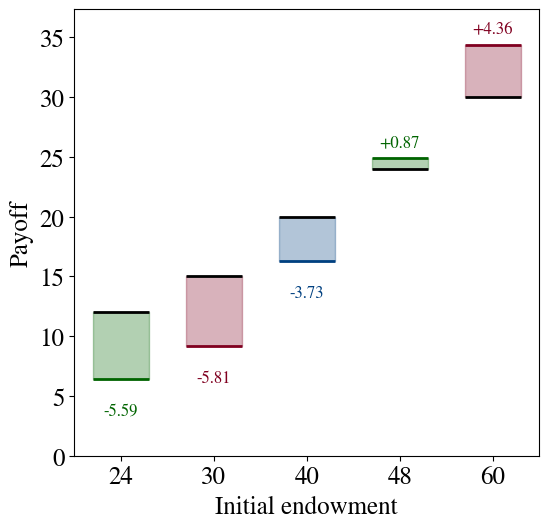

In [5]:
# Calculate mean payoffs, relative fairness, and differences
payoff_stats = successful_users_six.groupby(['control_wealth', 'endowment_initial'])['endowment_current'].agg(
    mean_payoff='mean'
).reset_index()
payoff_stats['relative_fairness'] = 0.5 * payoff_stats['endowment_initial']
payoff_stats['difference'] = payoff_stats['mean_payoff'] - payoff_stats['relative_fairness']

# Set up plot style
plt.figure(figsize=(6, 5.8))

# Plot settings
endowment_labels = sorted(payoff_stats['endowment_initial'].unique())
x_positions = np.arange(len(endowment_labels))

# Loop over each row in payoff_stats to plot horizontal lines and shaded areas
for i, row in payoff_stats.iterrows():
    initial_endowment = row['endowment_initial']
    mean_payoff = row['mean_payoff']
    relative_fairness = row['relative_fairness']
    difference = row['difference']
    control_wealth = row['control_wealth']
    x_pos = x_positions[endowment_labels.index(initial_endowment)]
    
    # Plot relative fairness line (black line for fairness threshold)
    plt.hlines(relative_fairness, x_pos - 0.3, x_pos + 0.3, colors='black', linewidth=2, label='Relative Fairness' if i == 0 else "")

    # Plot mean payoff line with color per control_wealth
    plt.hlines(mean_payoff, x_pos - 0.3, x_pos + 0.3, colors=wealth_colors[control_wealth], linewidth=2, label=control_wealth if i == 0 else "")
    
    # Shaded rectangle between relative fairness and mean payoff
    plt.fill_between([x_pos - 0.3, x_pos + 0.3],
                     relative_fairness, mean_payoff,
                     color=wealth_colors[control_wealth], alpha=0.3)
    
    # Annotate the difference
    text_y = mean_payoff + 1 if difference > 0 else mean_payoff - 3
    plt.text(x_pos, text_y, f'{difference:+.2f}', ha='center', color=wealth_colors[control_wealth], fontsize=12)

# Set categorical x-axis with equally spaced labels
plt.xticks(ticks=x_positions, labels=[str(e) for e in endowment_labels])

# Label and title
plt.xlabel("Initial endowment", fontsize=18)
plt.ylabel("Payoff", fontsize=18)
plt.tick_params(labelcolor='black', labelsize=18)

# Add a comprehensive legend with control wealth categories and fairness line
handles = [plt.Line2D([0], [0], color='black', lw=2, label='Relative Fairness')] + [
    plt.Line2D([0], [0], color=wealth_colors[cw], lw=2, label=cw) for cw in wealth_colors
]

# Adjust the limits and separate x and y axis visually
plt.ylim(0, max(payoff_stats['mean_payoff']) + 3)
plt.xlim(-0.5, len(endowment_labels) - 0.5)
plt.savefig("Figures/ExperimentalAnalysis/PayoffRelativeFairnessSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

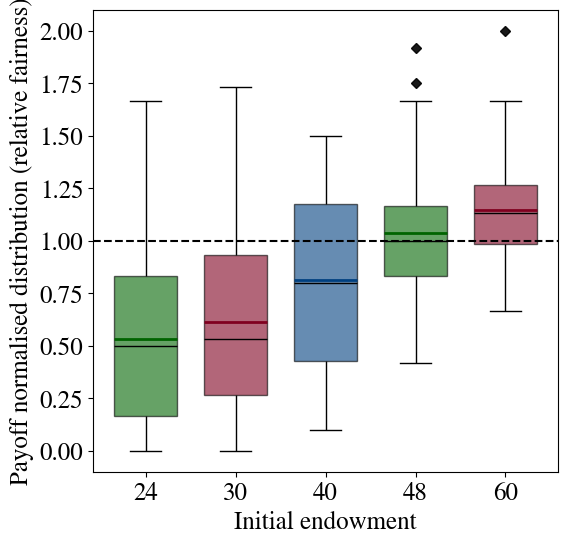

In [6]:
# Compute normalized payoffs and standard deviation
successful_users_six['normalized_payoff'] = successful_users_six['endowment_current'] / (0.5*successful_users_six['endowment_initial'])

plt.figure(figsize=(6, 6))

# Get unique endowment values and x positions
x_labels = sorted(successful_users_six['endowment_initial'].unique())
x_positions = range(len(x_labels))

# Plot each control_wealth separately
for control_wealth in successful_users_six['control_wealth'].unique():
    subset = successful_users_six[successful_users_six['control_wealth'] == control_wealth]
    color = wealth_colors[control_wealth]  # Assign color based on wealth category
    
    sns.boxplot(
        data=subset, 
        x='endowment_initial', 
        y='normalized_payoff', 
        order=x_labels,  # Ensures correct order of x positions
        boxprops={'facecolor': color, 'edgecolor': 'black', 'alpha':0.6},  # Manually set color
        medianprops=dict(color="black", linewidth=1),  # Highlight median
        whiskerprops={'color': 'black'},  # Whisker color
        capprops={'color': 'black'},  # Cap color
        width=0.7,  # Adjust box width
        showmeans=False,  # Adds mean points (but not lines)
        flierprops={
            'marker': 'D',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black',
            'markersize': 5,
            'alpha': 0.9
        },  # Use filled rhombus for outliers
    )

mean = successful_users_six.groupby(['control_wealth', 'endowment_initial'])['endowment_current'].agg(mean_payoff='mean').reset_index()
mean["mean_relative"]=mean["mean_payoff"]/(mean["endowment_initial"]*0.5)

# Loop over each row in payoff_stats to plot horizontal lines and shaded areas
for i, row in mean.iterrows():
    initial_endowment = row['endowment_initial']
    mean_payoff = row['mean_relative']
    control_wealth = row['control_wealth']
    x_pos = x_positions[x_labels.index(initial_endowment)]

    # Plot mean payoff line with color per control_wealth
    plt.hlines(mean_payoff, x_pos - 0.35, x_pos + 0.35, colors=wealth_colors[control_wealth], linewidth=2, label=control_wealth if i == 0 else "")

# Customize x-axis labels
plt.xticks(ticks=x_positions, labels=[str(label) for label in x_labels])
plt.xlabel("Initial endowment", fontsize=18)
plt.ylabel("Payoff normalised distribution (relative fairness)", fontsize=18)
plt.tick_params(labelcolor='black', labelsize=18)

# Create legend entries
legend_patches = [mpatches.Patch(color=color, alpha=0.6, label=label) for label, color in wealth_colors.items()]
legend_line = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=1.5, label="Fair Payoff")

# Add horizontal fairness line
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1.5, label="Fair Payoff")
plt.savefig("Figures/ExperimentalAnalysis/NormBoxPlotFinalPayoffSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

Average contribution and proportion of capital contributed by endowment
across wealth treatments.

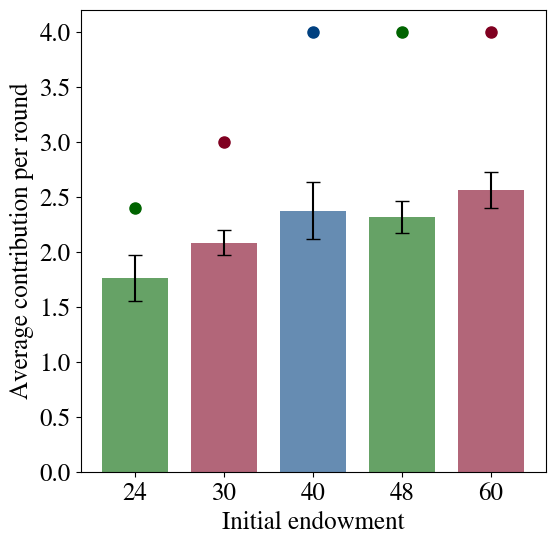

In [7]:
# Define maximum contributions and proportions per round and endowment
max_contribution_per_round = {40: 40/10, 24: 24/10, 48: 4, 30: 30/10, 60: 4}  # All max 4 per round

# Calculate per-user average contribution and standard deviation over rounds
successful_users_six['average_contribution'] = successful_users_six[round_columns].mean(axis=1)
successful_users_six['std_contribution'] = successful_users_six[round_columns].std(axis=1)

# Group by endowment and control_wealth to calculate mean and propagated error
grouped = successful_users_six.groupby(['endowment_initial', 'control_wealth']).agg(
    mean_contribution=('average_contribution', 'mean'),
    std_contribution=('std_contribution', lambda x: np.sqrt(np.sum(x**2)) / len(x))
).reset_index()

# Setting up the figure with equidistant bars
x_labels = sorted(grouped['endowment_initial'].unique())
x_positions = range(len(x_labels))

# Initialize dictionary to track which control_wealth labels have been added
added_labels = {cw: False for cw in wealth_colors.keys()}

# Average Contribution per Round for Each Endowment with Propagated Error
plt.figure(figsize=(6, 6))
for i, row in grouped.iterrows():
    endowment = row['endowment_initial']
    control_wealth = row['control_wealth']
    mean_contrib = row['mean_contribution']
    propagated_error = row['std_contribution']
    x_pos = x_labels.index(endowment)
    
    # Plot bar with propagated error bar, narrower and semi-transparent
    label = control_wealth if not added_labels[control_wealth] else ""
    plt.bar(x_pos, mean_contrib, color=wealth_colors[control_wealth], yerr=propagated_error, capsize=5, width=0.75, alpha=0.6, label=label)
    added_labels[control_wealth] = True  # Mark this control_wealth as labeled
    
    # Plot the dot for maximum contribution per round
    max_contrib = max_contribution_per_round[endowment]
    plt.plot(x_pos, max_contrib, 'o', color=wealth_colors[control_wealth], markersize=8)

    # Add a single black dot to the legend for "Max Contribution"
    if i == 0:  # add only once
        plt.plot([], [], 'o', color='black', markersize=8, label="Max Contribution")

# Customize the x-axis with equidistant labels
plt.xticks(ticks=x_positions, labels=[str(label) for label in x_labels])
plt.xlabel("Initial endowment", fontsize=18)
plt.ylabel("Average contribution per round", fontsize=18)
plt.tick_params(labelcolor='black', labelsize=18)

plt.savefig("Figures/ExperimentalAnalysis/AvContributionRoundSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

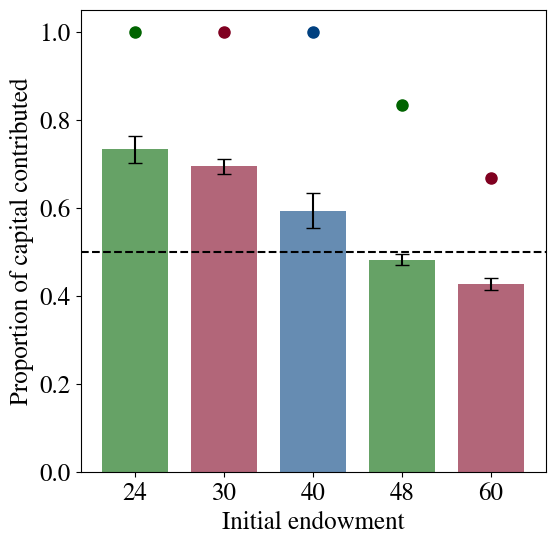

In [8]:
max_contribution_proportion = {40: 4*10/40, 24: 1, 48: 4*10/48, 30: 1, 60: 4*10/60}
# Calculate the proportion of capital contributed for each player
successful_users_six['proportion_contributed'] = successful_users_six['contributed_public_goods'] / successful_users_six['endowment_initial']

grouped_proportion = successful_users_six.groupby(['endowment_initial', 'control_wealth'])['proportion_contributed'].agg(
    mean_proportion='mean',
    std_proportion='std',
    count='size'
).reset_index()

grouped_proportion['stderr'] = grouped_proportion['std_proportion'] / np.sqrt(grouped_proportion['count'])

# Proportion of Capital Contributed with Propagated Error
plt.figure(figsize=(6, 6))
for i, row in grouped_proportion.iterrows():
    endowment = row['endowment_initial']
    control_wealth = row['control_wealth']
    mean_prop = row['mean_proportion']
    propagated_error_prop = row['stderr']
    x_pos = x_labels.index(endowment)
    
    # Plot bar with propagated error bar, broader and semi-transparent
    plt.bar(x_pos, mean_prop, color=wealth_colors[control_wealth], yerr=propagated_error_prop, capsize=5, width=0.75, alpha=0.6)
    
    # Plot the dot for maximum contribution proportion
    max_prop = max_contribution_proportion[endowment]
    plt.plot(x_pos, max_prop, 'o', color=wealth_colors[control_wealth], markersize=8)

# Add the fair contribution line at 0.5
plt.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Fair Contribution (50%)')

# Customize the x-axis with equidistant labels
plt.xticks(ticks=x_positions, labels=[str(label) for label in x_labels])
plt.xlabel("Initial endowment", fontsize=18)
plt.ylabel("Proportion of capital contributed", fontsize=18)
plt.tick_params(labelcolor='black', labelsize=18)
plt.savefig("Figures/ExperimentalAnalysis//PropCapitalContributedSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

Effect of generosity on the emergence of inequality.

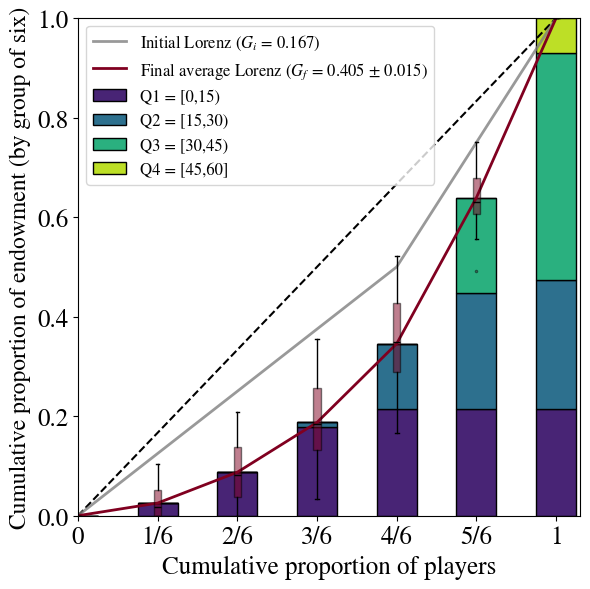

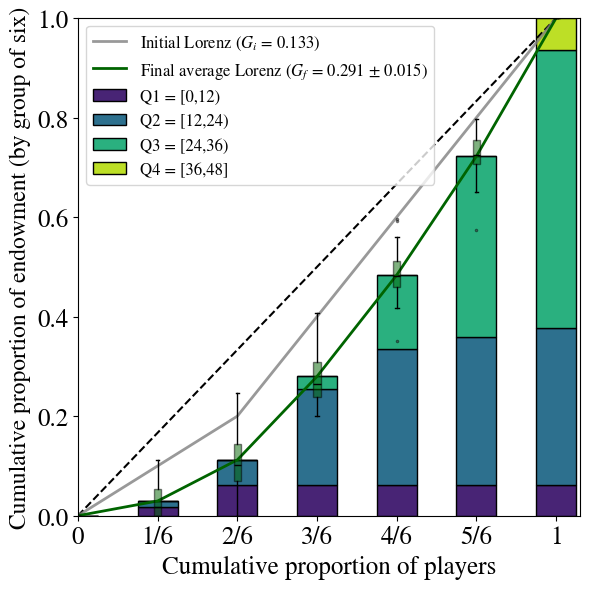

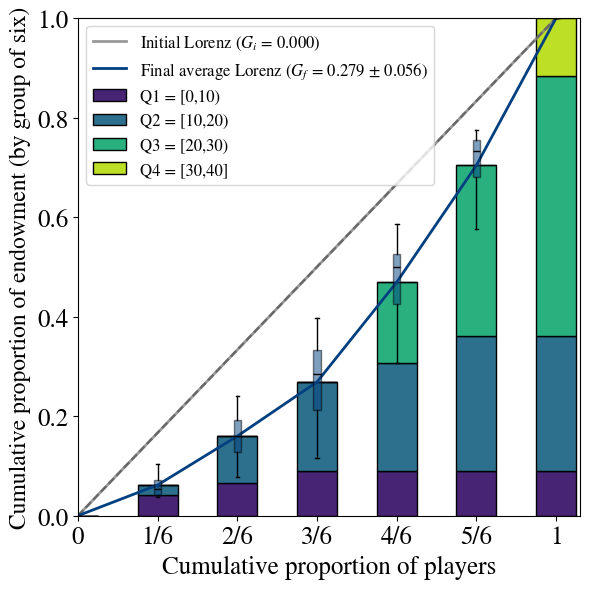

In [9]:
for control_wealth in successful_users_six["control_wealth"].unique():
    df_sub = successful_users_six[successful_users_six["control_wealth"] == control_wealth]

    max_endowment = df_sub["endowment_initial"].max()
    quartile_bins = [0.0, 0.25 * max_endowment, 0.5 * max_endowment, 0.75 * max_endowment, max_endowment + 1e-6]
    quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
    quartile_palette = cm.viridis(np.linspace(0.1, 0.9, len(quartile_labels)))
    quartile_color_map = dict(zip(quartile_labels, quartile_palette))

    lorenz_init_curves = []
    gini_init_list = []
    lorenz_final_curves = []
    gini_final_list = []
    stacked_quartile_contributions = {q: [] for q in quartile_labels}

    for partida_id, group in df_sub.groupby("partida_id"):
        x_init = group["endowment_initial"].values
        x_final = group["endowment_current"].values
        p_share, c_init = lorenz_curve(x_init)
        p_share, c_final = lorenz_curve(x_final)

        lorenz_init_curves.append(c_init)
        lorenz_final_curves.append(c_final)
        gini_init_list.append(gini_coeff(x_init))
        gini_final_list.append(gini_coeff(x_final))

        # Quartile assignment based on max initial endowment
        quartile_indices = pd.cut(x_final, bins=quartile_bins, labels=quartile_labels, include_lowest=True, right=False)
        df_quartile = pd.DataFrame({'income': x_final, 'quartile': quartile_indices}).sort_values('income')

        # Compute stacked proportions
        income = df_quartile['income'].values
        total = income.sum()
        stacked_q = np.zeros((len(p_share), len(quartile_labels)))

        for i, val in enumerate(income):
            q = df_quartile.iloc[i]['quartile']
            idx = quartile_labels.index(q)
            if total > 0:
                stacked_q[i+1, idx] = val / total  # +1 for the leading zero in Lorenz
            else:
                stacked_q[i+1, idx] = 1/6

        stacked_q = np.cumsum(stacked_q, axis=0)
        for j, q in enumerate(quartile_labels):
            stacked_quartile_contributions[q].append(stacked_q[:, j])

    mean_init = np.mean(lorenz_init_curves, axis=0)
    mean_final = np.mean(lorenz_final_curves, axis=0)
    sem_final = np.std(lorenz_final_curves, axis=0, ddof=1) / np.sqrt(len(lorenz_final_curves))
    gini_init_avg = np.nanmean(gini_init_list)
    gini_final_avg = np.nanmean(gini_final_list)
    gini_final_err = np.nanstd(gini_final_list, ddof=1) / np.sqrt(len(gini_final_list))

    # Mean of quartile contributions at each position
    avg_contrib = {q: np.mean(stacked_quartile_contributions[q], axis=0) for q in quartile_labels}

    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', label="")

    plt.plot(p_share, mean_init, label=f"Initial Lorenz ($G_i$ = {gini_init_avg:.3f})",
                color='gray', linewidth=2, alpha=0.8)

    plt.plot(p_share, mean_final, label=f"Final average Lorenz ($G_f$ = {gini_final_avg:.3f} ± {gini_final_err:.3f})",
                color=wealth_colors[control_wealth], linewidth=2)

    # Create a boxplot at each p_share value
    positions = p_share  # These are your x-axis values
    lorenz_final_curves = np.array(lorenz_final_curves)
    data_to_plot = [lorenz_final_curves[:, i] for i in range(len(p_share))]

    # Create the boxplot manually (one per point)
    plt.boxplot(data_to_plot,
                positions=positions,
                widths=0.015,
                patch_artist=True,
                boxprops=dict(facecolor=wealth_colors[control_wealth], color='black', alpha=0.5),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='.', markerfacecolor='gray', markersize=3, linestyle='none', alpha=0.5),
                meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 16})

    # Plot stacked bar of proportions
    bottom = np.zeros_like(p_share)
    for q in quartile_labels:
        vals = avg_contrib[q]
        plt.bar(p_share, vals, bottom=bottom, width=1/12, align='center',
                    color=quartile_color_map[q], edgecolor='black',
                    label=f"{q} = [{quartile_bins[quartile_labels.index(q)]:.0f},{quartile_bins[quartile_labels.index(q)+1]:.0f}]" if q=="Q4" else
                    f"{q} = [{quartile_bins[quartile_labels.index(q)]:.0f},{quartile_bins[quartile_labels.index(q)+1]:.0f})"
                   )
        bottom += vals

    tick_positions = p_share
    tick_labels = ["0","1/6","2/6","3/6","4/6","5/6","1"]
    plt.xticks(tick_positions, tick_labels, fontsize=18)
    plt.yticks(fontsize=18)
    # Labels and styling
    plt.xlabel("Cumulative proportion of players", fontsize=18)
    plt.ylabel("Cumulative proportion of endowment (by group of six)", fontsize=17)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.001)
    plt.legend(fontsize=12, loc="upper left")
    plt.tight_layout()
    filename = f"Figures/ExperimentalAnalysis/LorenzQuartiles_{str(control_wealth)}.pdf"
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.2)
    plt.show()

#### Temporal dynamics of cooperation

Temporal evolution of contributions across rounds.

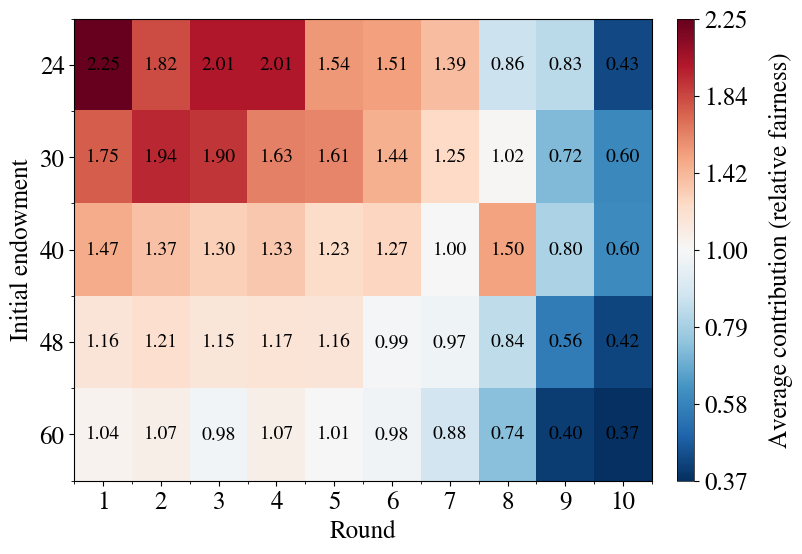

In [10]:
# Placeholder for average contribution results
average_contribution_results_real = []

df=successful_users_six.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    for round_index, round_col in enumerate(round_columns):
        for endowment, endowment_data in game_data.groupby("endowment_initial"):
            avg_contribution = endowment_data[round_col].mean()  # Average contribution for this endowment in this round

            average_contribution_results_real.append({
                "partida_id": partida_id,
                "control_wealth": game_data["control_wealth"].iloc[0],
                "endowment_initial": endowment,
                "round": round_col,
                "average_contribution": avg_contribution/(0.5*endowment/10)
            })

# Convert to DataFrame
df_avg_contrib = pd.DataFrame(average_contribution_results_real)

# Compute average contributions for each `endowment_initial` and `round`
avg_contribution_matrix_real = df_avg_contrib.groupby(
    ["endowment_initial", "round"]
)["average_contribution"].mean().unstack()
# Reorder columns to ensure rounds are in the correct order
avg_contribution_matrix_real = avg_contribution_matrix_real[['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10']]
avg_contribution_matrix_real

# Create heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

min_height=avg_contribution_matrix_real.min().min()
max_height=avg_contribution_matrix_real.max().max()
midpoint = 1  # Value at which white color will be centered
norm = colors.TwoSlopeNorm(vmin=min_height, vcenter=midpoint, vmax=max_height)
cmap = plt.colormaps.get_cmap('RdBu_r')

ax.imshow(avg_contribution_matrix_real, cmap=cmap, norm=norm, aspect="auto",origin="upper", interpolation="nearest")

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad=0.25)
colorbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cax, orientation='vertical', label='Simpson-Citywide')
colorbar.ax.tick_params(labelsize=18)
colorbar.set_label('Average contribution (relative fairness)', fontsize=18, labelpad=15)

# Set the number of ticks on the colorbar
num_ticks = 3  # This gives you 2 positive ticks + 0 + 2 negative ticks
positive_ticks = np.linspace(midpoint, max_height, num=num_ticks+1)[1:]  # Exclude 0 for positive ticks
negative_ticks = np.linspace(min_height, midpoint, num=num_ticks+1)[:-1]  # Exclude 0 for negative ticks

# Concatenate negative ticks, zero, and positive ticks
tick_values = np.concatenate([negative_ticks, [midpoint], positive_ticks])    
tick_labels = [f'{tick:.2f}' for tick in tick_values]

colorbar.set_ticks(tick_values)
colorbar.set_ticklabels(tick_labels)
colorbar.outline.set_linewidth(0.5)  # Adjust the linewidth as needed

# Ensure correct label alignment
x_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
ax.set_xticks(np.arange(len(round_columns)))
ax.set_xticklabels(x_labels)#, rotation=45, ha="right")
ax.set_yticks(np.arange(len(avg_contribution_matrix_real.index)))
ax.set_yticklabels(avg_contribution_matrix_real.index)

# Remove white grid lines
ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(avg_contribution_matrix_real.index), 1), minor=True)
ax.grid(False, which="both")  # Remove grid lines
ax.tick_params(labelcolor='black', labelsize=18)
# Annotate the values (ensuring correct alignment)
for i in range(len(avg_contribution_matrix_real.index)):  # Iterate over rows
    for j in range(len(round_columns)):  # Iterate over columns
        value = avg_contribution_matrix_real.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=14)

# Labels and title
ax.set_xlabel("Round", fontsize=18)
ax.set_ylabel("Initial endowment", fontsize=18)

plt.savefig("Figures/ExperimentalAnalysis/AverageContributionRoundSUCCESSFAIR.pdf", bbox_inches='tight', pad_inches=0.1)
# Show plot
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_22416\3981407668.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis_colors = cm.get_cmap('RdBu_r', num_contributions)


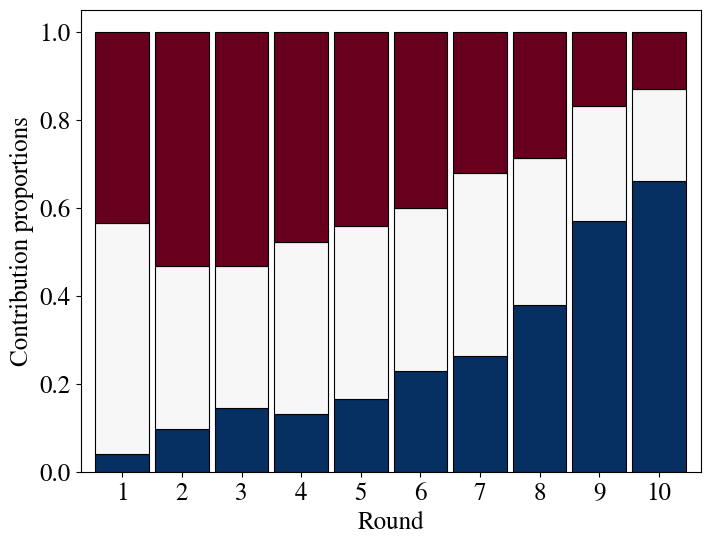

In [11]:
#STACKED BAR PLOTS FOR CONTRIBUTION CHOICES PER ROUND
# Reshape data for easier processing
round_data = pd.melt(successful_users_six, id_vars=[], value_vars=round_columns,
                      var_name="Round", value_name="Contribution")

# Explicitly define categorical ordering for rounds
round_data["Round"] = pd.Categorical(round_data["Round"], categories=round_columns, ordered=True)

# Compute counts for each contribution option per round
crosstab = pd.crosstab(round_data["Round"], round_data["Contribution"])

# Normalize row-wise (each round sums to 1)
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

# Ensure column names are strings for proper labeling
crosstab_norm.columns = crosstab_norm.columns.astype(str)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Get Viridis colormap with as many colors as contribution levels
num_contributions = crosstab_norm.shape[1]
viridis_colors = cm.get_cmap('RdBu_r', num_contributions)

# Convert colormap to color list
color_list = [viridis_colors(i) for i in range(num_contributions)]

# Plot with custom colors
crosstab_norm.plot(kind='bar', stacked=True, ax=ax, width=0.9,
                   edgecolor="black", linewidth=0.8,
                   color=color_list)

# Labels & Formatting
ax.set_xlabel("Round", fontsize=18)
ax.set_ylabel("Contribution proportions", fontsize=18)

# Correct x-axis tick labels
x_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
ax.set_xticks(np.arange(len(round_columns)))
ax.set_xticklabels(x_labels, fontsize=18, rotation=0)

# Remove legend
ax.get_legend().remove()

# Y-axis formatting
ax.set_ylim(0, 1.05)
ax.tick_params(labelcolor='black', labelsize=18)

# Save
plt.savefig("Figures/ExperimentalAnalysis/ContributionProportionALLSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

Temporal evolution of the common fund and goal attainment.

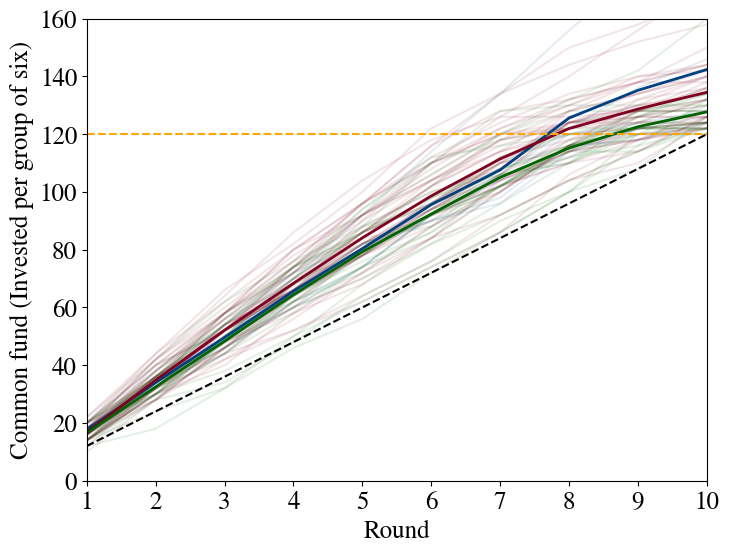

In [12]:
# Placeholder for storing the round where each partida_id reaches the goal
cumulative_results = []

df=successful_users_six.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    cumulative_round = {}  # Track cumulative contribution over rounds
    cumulative_contribution = 0  # Track cumulative contribution over rounds

    for round_index, round_col in enumerate(round_columns):
        # Update cumulative contribution for all players up to this round
        cumulative_contribution += game_data[round_col].sum()
        cumulative_round[f"R{round_index + 1}"] = cumulative_contribution
    # Store the result for each control wealth
    cumulative_results.append({
        "partida_id": partida_id,
        "control_wealth": game_data["control_wealth"].iloc[0],
        **cumulative_round
    })

# Convert to DataFrame
df_cumulative = pd.DataFrame(cumulative_results)

# Create a figure
plt.figure(figsize=(8, 6))

# Ensure `df_cumulative` contains necessary columns
df_games_rounds = df_cumulative[['control_wealth'] + round_columns]

# Group by control_wealth and calculate the mean target distance per round.
mean_target_distance = df_games_rounds.groupby('control_wealth').mean()

# Plot all individual trajectories with transparency
for _, row in df_games_rounds.iterrows():
    wealth_type = row["control_wealth"]
    plt.plot(range(1, 11), row[round_columns], color=wealth_colors[wealth_type], alpha=0.1)

# Plot mean trajectory per control wealth
for wealth_type in mean_target_distance.index:
    plt.plot(range(1, 11), mean_target_distance.loc[wealth_type], label=f'{wealth_type}', 
             color=wealth_colors[wealth_type], linewidth=2)

# Add dashed black line at 120 with label "GOAL"
plt.axhline(y=120, color='orange', linestyle='dashed', linewidth=1.5, label="Goal")

# Add cumulative fair contribution line (slope 1, finishing at 120 at round 10)
plt.plot(range(1, 11), np.linspace(12, 120, 10), color='black', linestyle='dashed', linewidth=1.5, label="Cumulative fair contribution")

# Formatting
plt.xlabel("Round", fontsize=18)
plt.ylabel("Common fund (Invested per group of six)", fontsize=18)
plt.tick_params(labelcolor='black', labelsize=18)
plt.xticks(range(1, 11))
plt.yticks(range(0, 180, 20))
plt.ylim(0, 160)
plt.xlim(1, 10)

plt.savefig("Figures/ExperimentalAnalysis/CumulativePOTWealthSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
# Show plot
plt.show()

control_wealth
EQUAL        8.400000
UNEQUAL-H    8.309524
UNEQUAL-L    8.777778
Name: goal_reached_round, dtype: float64


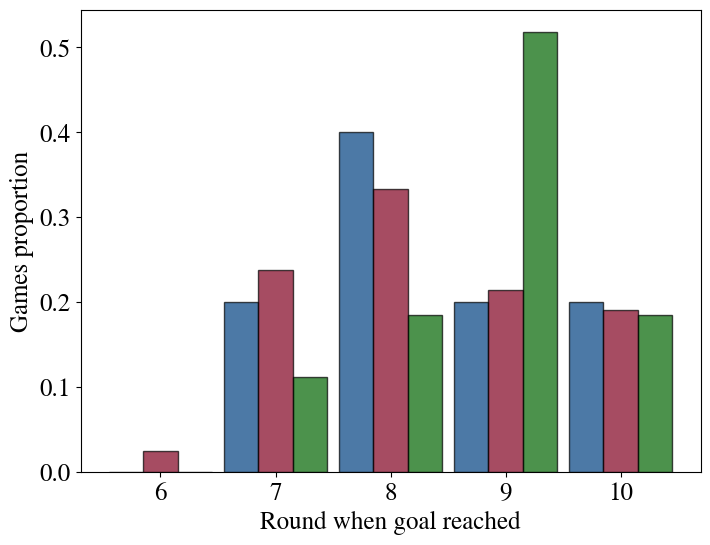

In [ ]:
# Placeholder for storing the round where each partida_id reaches the goal
goal_reach_results = []

df=successful_users_six.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    cumulative_contribution = 0  # Track cumulative contribution over rounds
    goal_reached_round = None

    for round_index, round_col in enumerate(round_columns):
        # Update cumulative contribution for all players up to this round
        cumulative_contribution += game_data[round_col].sum()

        # Check if the goal of 120 coins has been reached
        if cumulative_contribution >= 120 and goal_reached_round is None:
            goal_reached_round = round_index + 1  # Store the round (1-based index)
            break  # Stop checking further rounds once the goal is reached

    # Store the result for each control wealth
    goal_reach_results.append({
        "partida_id": partida_id,
        "control_wealth": game_data["control_wealth"].iloc[0],
        "goal_reached_round": goal_reached_round
    })

# Convert to DataFrame
df_goal_reach = pd.DataFrame(goal_reach_results)

# Compute the average round when the goal was reached, grouped by endowment
avg_goal_reach_by_endowment = df_goal_reach.groupby("control_wealth")["goal_reached_round"].mean()

# Display results
print(avg_goal_reach_by_endowment)

# Compute counts of games reaching the goal in each round, grouped by control wealth
goal_reach_counts = df_goal_reach.groupby(["goal_reached_round", "control_wealth"]).size().unstack(fill_value=0)

# Normalize each control wealth column so the sum over rounds equals 1
goal_reach_counts_normalized = goal_reach_counts.div(goal_reach_counts.sum(axis=0), axis=1)

# Plot normalized histogram with error bars
fig, ax = plt.subplots(figsize=(8, 6))

# Bar width for separation
bar_width = 0.3
x_positions = np.arange(len(goal_reach_counts.index))

# Iterate through each control wealth and plot bars
for i, control_wealth in enumerate(goal_reach_counts_normalized.columns):
    ax.bar(x_positions + i * bar_width, goal_reach_counts_normalized[control_wealth], width=bar_width,
           label=f'{control_wealth} (avg: {avg_goal_reach_by_endowment[control_wealth]:.2f})', color=wealth_colors[control_wealth], edgecolor="black", alpha=0.7)

# Formatting
ax.set_xticks(x_positions + bar_width)  # Center labels
ax.set_xticklabels(goal_reach_counts.index, fontsize=18)
ax.tick_params(labelcolor='black', labelsize=18)
ax.set_xlabel("Round when goal reached", fontsize=18)
ax.set_ylabel("Games proportion", fontsize=18)

plt.savefig("Figures/ExperimentalAnalysis/ProportionReachingGoalRoundSUCCESS.pdf", bbox_inches='tight', pad_inches=0.1)
# Show plot
plt.show()

### Computing all real macro-observables and storing them into a dataset

In [ ]:
# from functions.py
df_macro_real = compute_macro_observables(successful_users_six)
df_macro_real.to_csv("Datasets/Observables_Data.csv", index=False)
df_macro_real

,endowment_initial,Gini_initial,Average_gini_after,Average_round_reached,Count_games_reached,Proportion_games_reached,Payoff,Payoff_relative_fairness,Proportion_contributed,Average_contribution,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
0,24,0.133333,0.290868,8.777778,27,1.0,6.407407,0.533951,0.733025,1.759259,2.703704,2.185185,2.407407,2.407407,1.851852,1.814815,1.666667,1.037037,1.000000,0.518519
1,30,0.166667,0.405019,8.309524,42,1.0,9.190476,0.612698,0.693651,2.080952,2.630952,2.916667,2.845238,2.452381,2.416667,2.166667,1.880952,1.523810,1.083333,0.892857
2,40,0.000000,0.278810,8.400000,5,1.0,16.266667,0.813333,0.593333,2.373333,2.933333,2.733333,2.600000,2.666667,2.466667,2.533333,2.000000,3.000000,1.600000,1.200000
3,48,0.133333,0.290868,8.777778,27,1.0,24.870370,1.036265,0.481867,2.312963,2.777778,2.907407,2.759259,2.814815,2.777778,2.370370,2.333333,2.018519,1.351852,1.018519
4,60,0.166667,0.405019,8.309524,42,1.0,34.357143,1.145238,0.427381,2.564286,3.119048,3.214286,2.952381,3.214286,3.023810,2.928571,2.642857,2.214286,1.214286,1.119048
